## CISD 43- Trader Joe's - REDDIT


CISD 43 
Christina Perez De-Haro

### Intro.

Scraping the subreddit 'r/traderjoes and preforming a text analysis 

### Installation of Required Libraries

In [4]:

! pip install emoji
! pip install textblob
! pip install wordcloud
! pip install nltk

In [162]:

import time
import sys
import pandas as pd
import numpy as np
import json
import re
import emoji
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


### Scraping with JSON

#### Access JSON file 

In [145]:
## default JSON Reddit caps results at 100 posts per request
subreddit = 'traderjoes'
limit = 100
timeframe = 'all' #hour, day, week, month, year, all
#listing = 'top' # controversial, best, hot, new, random, rising, top
  
def get_reddit(subreddit,listing,limit,timeframe):
    try:
        base_url = f'https://www.reddit.com/r/{subreddit}.json?limit={limit}&t={timeframe}'
        request = requests.get(base_url, headers = {'User-agent': 'Practical-Ideal4175'})
    except:
        print('An Error Occured')
    return request.json()
  
tj_reddit = get_reddit(subreddit,listing,limit,timeframe)


### Converting JSON to Dataframe

In [148]:

df = pd.json_normalize(tj_reddit["data"]["children"])
print(df.shape)
df.head(5)

(100, 541)


,kind,data.approved_at_utc,data.subreddit,data.selftext,data.author_fullname,data.saved,data.mod_reason_title,data.gilded,data.clicked,data.title,...,data.media_metadata.bz1x9rnga0xg1.s.u,data.media_metadata.bz1x9rnga0xg1.id,data.media_metadata.t4lhornga0xg1.status,data.media_metadata.t4lhornga0xg1.e,data.media_metadata.t4lhornga0xg1.m,data.media_metadata.t4lhornga0xg1.p,data.media_metadata.t4lhornga0xg1.s.y,data.media_metadata.t4lhornga0xg1.s.x,data.media_metadata.t4lhornga0xg1.s.u,data.media_metadata.t4lhornga0xg1.id
0,t3,None,traderjoes,The large tote bag is expected to be the same ...,t2_5jtaw2pc,False,None,0,False,Megathread: Trader Joe’s Large Lavender Reusab...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,t3,None,traderjoes,For Pastel Mini Tote Bags - Many stores are es...,t2_5jtaw2pc,False,None,0,False,March 2026 Update: Trader Joe's Pastel Mini Ca...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,t3,None,traderjoes,"My boyfriend's review: ""Holy F--- what are tho...",t2_q6ceemw,False,None,0,False,Cookies &amp; Creme Cookie Mix (Review),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,t3,None,traderjoes,Has anyone tried the Meyer lemon cake mix?,t2_1idfs402kc,False,None,0,False,Is the Meyer lemon cake mix good?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,t3,None,traderjoes,I went to my local Trader Joe’s today after my...,t2_1a31siy529,False,None,0,False,One of the best days I’ve had in a while - Lefse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Exploring/Cleaning data 

In [151]:
df.columns

Index(['kind', 'data.approved_at_utc', 'data.subreddit', 'data.selftext',
       'data.author_fullname', 'data.saved', 'data.mod_reason_title',
       'data.gilded', 'data.clicked', 'data.title',
       ...
       'data.media_metadata.bz1x9rnga0xg1.s.u',
       'data.media_metadata.bz1x9rnga0xg1.id',
       'data.media_metadata.t4lhornga0xg1.status',
       'data.media_metadata.t4lhornga0xg1.e',
       'data.media_metadata.t4lhornga0xg1.m',
       'data.media_metadata.t4lhornga0xg1.p',
       'data.media_metadata.t4lhornga0xg1.s.y',
       'data.media_metadata.t4lhornga0xg1.s.x',
       'data.media_metadata.t4lhornga0xg1.s.u',
       'data.media_metadata.t4lhornga0xg1.id'],
      dtype='object', length=541)

#### Cleaning up the data 

In [102]:
# Selecting only the relevant columns
cols = [
    "data.title",
    "data.author",
    "data.subreddit",
    "data.upvote_ratio",
    "data.total_awards_received",
    "data.permalink",
    "data.created_utc",
    "data.selftext"
]

df_clean = df[cols]


df_clean.columns = [c.replace("data.", "") for c in df_clean.columns]

# Converting the timestamp to a readable date
from datetime import datetime
df_clean["created_utc"] = pd.to_datetime(df_clean["created_utc"], unit="s")

df_clean = df_clean.sort_values("created_utc", ascending=False).reset_index(drop=True)
print(df_clean.shape)
df_clean.head(10)

(100, 8)


C:\Users\tinap\AppData\Local\Temp\ipykernel_23120\3120131003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["created_utc"] = pd.to_datetime(df_clean["created_utc"], unit="s")


,title,author,subreddit,upvote_ratio,total_awards_received,permalink,created_utc,selftext
0,Synergistically seasoned popcorn,makooba,traderjoes,0.95,0,/r/traderjoes/comments/1t23gej/synergistically...,2026-05-02 22:13:31,Amazing! Perfectly described on the bag. 160 c...
1,Review: Costa Rica Coffee - small lot,BlueKayak,traderjoes,0.92,0,/r/traderjoes/comments/1t23d0d/review_costa_ri...,2026-05-02 22:09:23,[https://www.traderjoes.com/home/products/pdp/...
2,Cookies &amp; Creme Cookie Mix (Review),bunnyfloofington,traderjoes,0.98,0,/r/traderjoes/comments/1t20131/cookies_creme_c...,2026-05-02 19:56:43,"My boyfriend's review: ""Holy F--- what are tho..."
3,Is the Meyer lemon cake mix good?,NoCaterpillar800,traderjoes,0.98,0,/r/traderjoes/comments/1t1xm6u/is_the_meyer_le...,2026-05-02 18:24:58,Has anyone tried the Meyer lemon cake mix?
4,One of the best days I’ve had in a while - Lefse,Northern_Lights_2,traderjoes,0.98,0,/r/traderjoes/comments/1t1fpfl/one_of_the_best...,2026-05-02 04:24:10,I went to my local Trader Joe’s today after my...
5,Sea salt chocolate chunk cookies,Churlishbeast,traderjoes,0.55,0,/r/traderjoes/comments/1t1eiab/sea_salt_chocol...,2026-05-02 03:23:54,I bought these not knowing what to expect but ...
6,Taco Seasoned Gouda Cheese is incredible!!,lankaxhandle,traderjoes,0.93,0,/r/traderjoes/comments/1t1e49u/taco_seasoned_g...,2026-05-02 03:05:10,This stuff is phenomenal! I ate a good chunk p...
7,"Trader Joe’s dupes and skincare: hair oil, bod...",Just_Art_6537,traderjoes,0.82,0,/r/traderjoes/comments/1t1dt2z/trader_joes_dup...,2026-05-02 02:50:32,I’m from Costa Rica and going to the states on...
8,Spicy Spuds turned into Cheesy Fiesta Potatoes🛎️🌮,Old_Bottle_2453,traderjoes,0.97,0,/r/traderjoes/comments/1t1da0j/spicy_spuds_tur...,2026-05-02 02:24:58,I used the spicy spuds 🥔 to make makeshift che...
9,Need to make small emergency prom bouquets/nos...,beockwaymetcalf,traderjoes,0.50,0,/r/traderjoes/comments/1t1c99p/need_to_make_sm...,2026-05-02 01:36:51,I just talked my kid and their pal into flower...


In [154]:
# replacing "" with nan
df_clean["selftext"] = df_clean["selftext"].replace("", np.nan)
# creating columns that fills empty selftext with the title text
df_clean["col_text"] = df_clean["selftext"].fillna(df_clean["title"])
# displaying differences 
df_clean[["col_text", "title",'selftext']]

,col_text,title,selftext
0,Amazing! Perfectly described on the bag. 160 c...,Synergistically seasoned popcorn,Amazing! Perfectly described on the bag. 160 c...
1,[https://www.traderjoes.com/home/products/pdp/...,Review: Costa Rica Coffee - small lot,[https://www.traderjoes.com/home/products/pdp/...
2,"My boyfriend's review: ""Holy F--- what are tho...",Cookies &amp; Creme Cookie Mix (Review),"My boyfriend's review: ""Holy F--- what are tho..."
3,Has anyone tried the Meyer lemon cake mix?,Is the Meyer lemon cake mix good?,Has anyone tried the Meyer lemon cake mix?
4,I went to my local Trader Joe’s today after my...,One of the best days I’ve had in a while - Lefse,I went to my local Trader Joe’s today after my...
...,...,...,...
95,Organic Conversation Olive Trio,Organic Conversation Olive Trio,NaN
96,I’m so excited that the Jalapeño limeade is ba...,The organic Jalapeño limeade is back!,I’m so excited that the Jalapeño limeade is ba...
97,Confirmed at my local store that the savory sq...,Savory Squares Returning end of month!!,Confirmed at my local store that the savory sq...
98,The large tote bag is expected to be the same ...,Megathread: Trader Joe’s Large Lavender Reusab...,The large tote bag is expected to be the same ...


#### Cleaning text data

In [160]:
def clean_text(text):
    """Clean transcript text by removing extra spaces and line breaks."""
    text = str(text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    text = emoji.demojize(text)
    return text.strip()


if not df_clean.empty:
    df_clean["clean_text"] = df_clean["col_text"].apply(clean_text)
    display(df_clean[["col_text", "clean_text"]])

,col_text,clean_text
0,Amazing! Perfectly described on the bag. 160 c...,Amazing! Perfectly described on the bag. 160 c...
1,[https://www.traderjoes.com/home/products/pdp/...,[https://www.traderjoes.com/home/products/pdp/...
2,"My boyfriend's review: ""Holy F--- what are tho...","My boyfriend's review: ""Holy F--- what are tho..."
3,Has anyone tried the Meyer lemon cake mix?,Has anyone tried the Meyer lemon cake mix?
4,I went to my local Trader Joe’s today after my...,I went to my local Trader Joe’s today after my...
...,...,...
95,Organic Conversation Olive Trio,Organic Conversation Olive Trio
96,I’m so excited that the Jalapeño limeade is ba...,I’m so excited that the Jalapeño limeade is ba...
97,Confirmed at my local store that the savory sq...,Confirmed at my local store that the savory sq...
98,The large tote bag is expected to be the same ...,The large tote bag is expected to be the same ...


## Analyzing Sentiment

### Polarity

In [115]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity


def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity


if not df_clean.empty:
    df_clean["polarity"] = df_clean["clean_text"].apply(get_polarity)
    df_clean["subjectivity"] = df_clean["clean_text"].apply(get_subjectivity)

    display(df_clean[["clean_text", "polarity", "subjectivity"]].head())

,clean_text,polarity,subjectivity
0,Amazing! Perfectly described on the bag. 160 c...,0.875000,0.950000
1,[https://www.traderjoes.com/home/products/pdp/...,0.019048,0.288095
2,"My boyfriend's review: ""Holy F--- what are tho...",0.750000,0.575000
3,Has anyone tried the Meyer lemon cake mix?,0.000000,0.000000
4,I went to my local Trader Joe’s today after my...,0.069616,0.493101


### Sentiment

In [169]:
def sentiment_label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"


if not df.empty:
    df_clean["sentiment"] = df_clean["polarity"].apply(sentiment_label)
    display(df_clean[["clean_text", "polarity", "sentiment"]].head())

,clean_text,polarity,sentiment
0,Amazing! Perfectly described on the bag. 160 c...,0.875000,Positive
1,[https://www.traderjoes.com/home/products/pdp/...,0.019048,Positive
2,"My boyfriend's review: ""Holy F--- what are tho...",0.750000,Positive
3,Has anyone tried the Meyer lemon cake mix?,0.000000,Neutral
4,I went to my local Trader Joe’s today after my...,0.069616,Positive


In [171]:
if not df_clean.empty:
    sentiment_counts = df_clean["sentiment"].value_counts().reset_index()
    sentiment_counts.columns = ["Sentiment", "Count"]
    display(sentiment_counts)

,Sentiment,Count
0,Positive,78
1,Negative,12
2,Neutral,10


### Visualizations

#### bar chart

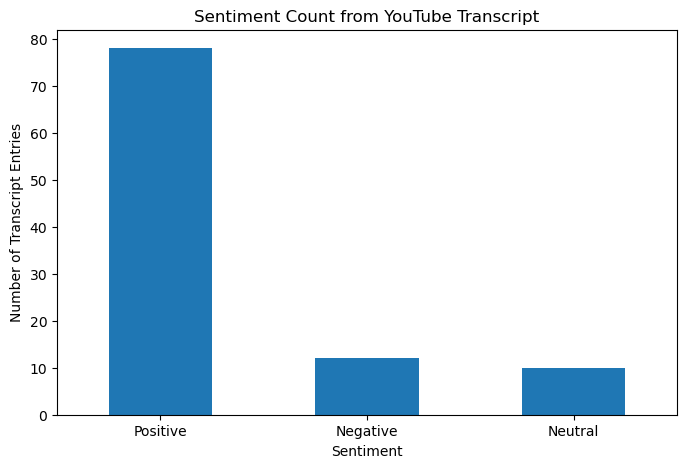

In [174]:
if not df_clean.empty:
    sentiment_counts.plot(kind="bar", x="Sentiment", y="Count", legend=False, figsize=(8, 5))
    plt.title("Sentiment Count from YouTube Transcript")
    plt.xlabel("Sentiment")
    plt.ylabel("Number of Transcript Entries")
    plt.xticks(rotation=0)
    plt.show()

#### Pie Chart

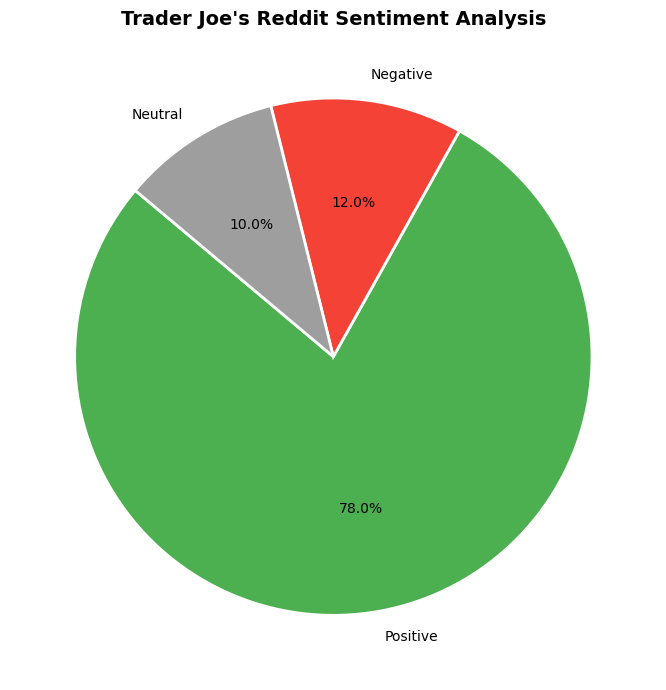

In [178]:


# Count sentiment categories
sentiment_counts = df_clean["sentiment"].value_counts()

# Define colors
colors = ["#4CAF50", "#F44336", "#9E9E9E"]  # green, red, grey

# Plot
plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    colors=colors,
    autopct="%1.1f%%",      # show percentage on each slice
    startangle=140,          # rotate starting angle
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title("Trader Joe's Reddit Sentiment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

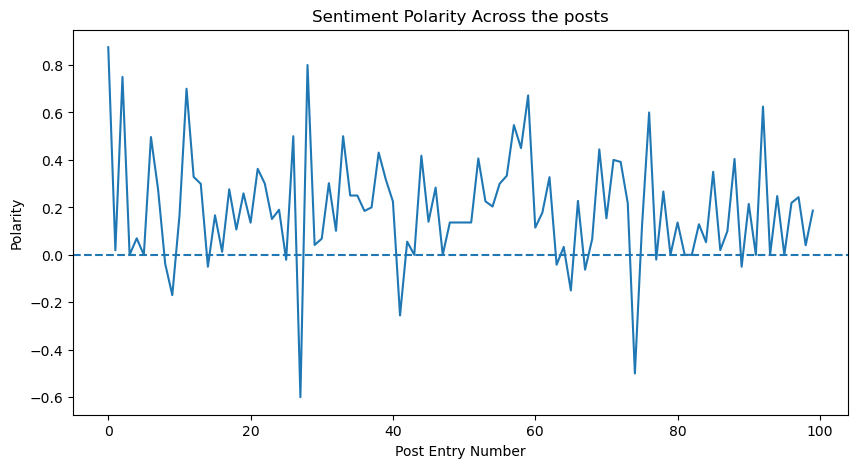

In [125]:
if not df_clean.empty:
    plt.figure(figsize=(10, 5))
    #plt.plot(df_clean.index, df_clean["polarity"])
    plt.plot(df_clean.index, df_clean["polarity"])
    plt.axhline(0, linestyle="--")
    plt.title("Sentiment Polarity Across the posts")
    plt.xlabel("Post Entry Number")
    plt.ylabel("Polarity")
    plt.show()

#### Word Blobs

In [129]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')  # ← updated name

from nltk.tokenize import word_tokenize
from nltk import pos_tag

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tinap\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\tinap\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


#### Word blobs of words in text that are tokenized as an adjective

In [203]:

full_text = " ".join(df_clean["clean_text"].dropna().tolist())

tokens = word_tokenize(full_text)
tagged_tokens = pos_tag(tokens)

vbz_list = [token for token, tag in tagged_tokens if tag in ['JJ', 'JJR', 'JJS','ADJ']]


#### Combine the token words into One Text

In [206]:
if vbz_list: 
    full_text = " ".join(vbz_list)
    print("Total characters in transcript:", len(full_text))
    print()
    print(full_text[:500])
else:
    full_text = ""
    print("No transcript text is available.")

Total characters in transcript: 3374

cal [ //www.traderjoes.com/home/products/pdp/costa-rica-coffee-081522 https //www.traderjoes.com/home/products/pdp/costa-rica-coffee-081522 dark other next hard delicious top Best boxed lemon local ’ abysmal ’ proper ’ lovely more difficult such bright insane only cold ’ much grown flat bread salty phenomenal good ve good ve mixed ’ ’ ’ ’ t limited friendly good im fine cant sour better na mango pineapple next black other little good m burnt doesn favorite unexpected sprouted amazing i shredded 


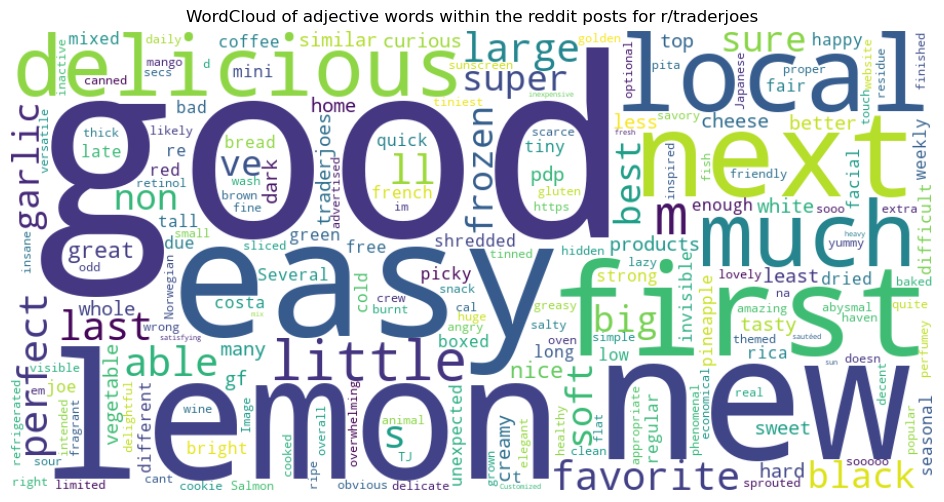

In [210]:
if vbz_list:
    custom_stopwords = set(STOPWORDS)

    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        stopwords=custom_stopwords,
        collocations=False
    ).generate(full_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud of adjective words within the reddit posts for r/traderjoes")
    plt.show()
else:
    print("No transcript text is available for the WordCloud.")

#### Combine all posts into one text

In [213]:
if not df_clean.empty:
    full_text = " ".join(df_clean["clean_text"].dropna().tolist())
    

    print("Total characters in transcript:", len(full_text))
    print()
    print(full_text[:500])
else:
    full_text = ""
    print("No transcript text is available.")

Total characters in transcript: 29524

Amazing! Perfectly described on the bag. 160 cal for 3 cups. [https://www.traderjoes.com/home/products/pdp/costa-rica-coffee-081522](https://www.traderjoes.com/home/products/pdp/costa-rica-coffee-081522) I saw these beans show up in our store (Northern Calif) about a week ago. The bag said "Medium roast" but with TJs it's a crapshoot on how dark they really are. I kept checking to see if any reviews on these beans had been posted here or other coffee forums, but no luck. Decided to bite the bull


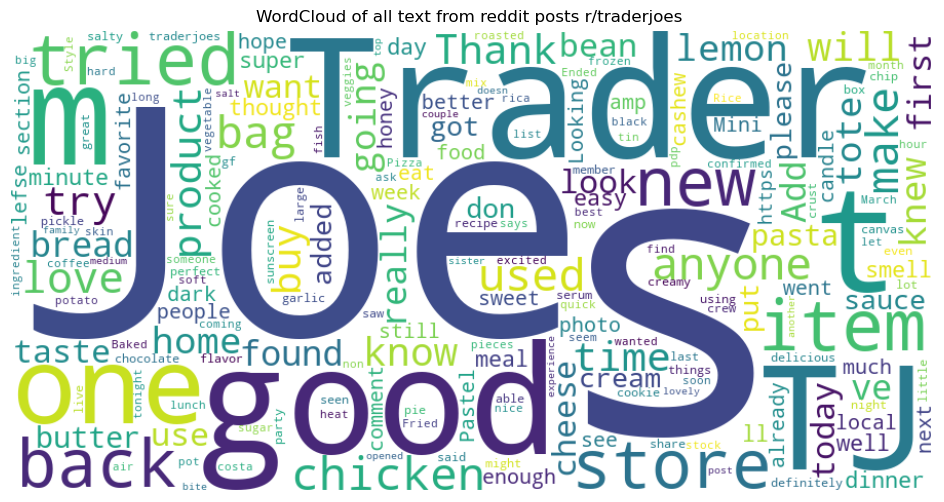

In [217]:
if full_text.strip():
    custom_stopwords = set(STOPWORDS)

    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        stopwords=custom_stopwords,
        collocations=False
    ).generate(full_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud of all text from reddit posts r/traderjoes ")
    plt.show()
else:
    print("No transcript text is available for the WordCloud.")

## References

- https://roundproxies.com/blog/reddit/
- https://www.jcchouinard.com/documentation-on-reddit-apis-json/
- https://medium.com/@ebimsv/nlp-series-day-5-handling-emojis-strategies-and-code-implementation-0f8e77e3a25c
- https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html
- https://medium.com/@danielwume/getting-started-with-nltk-10-essential-examples-for-natural-language-processing-in-python-54451eae1366
- https://www.nltk.org/book/ch05.html
- https://stackoverflow.com/questions/71974922/is-there-a-way-to-filter-out-all-adjectives-from-a-string-and-store-them-in-an-a

#### Notebook Examples

- Tutorial Sentiment Analysis with TextBlob
- youtube_MCM_Review